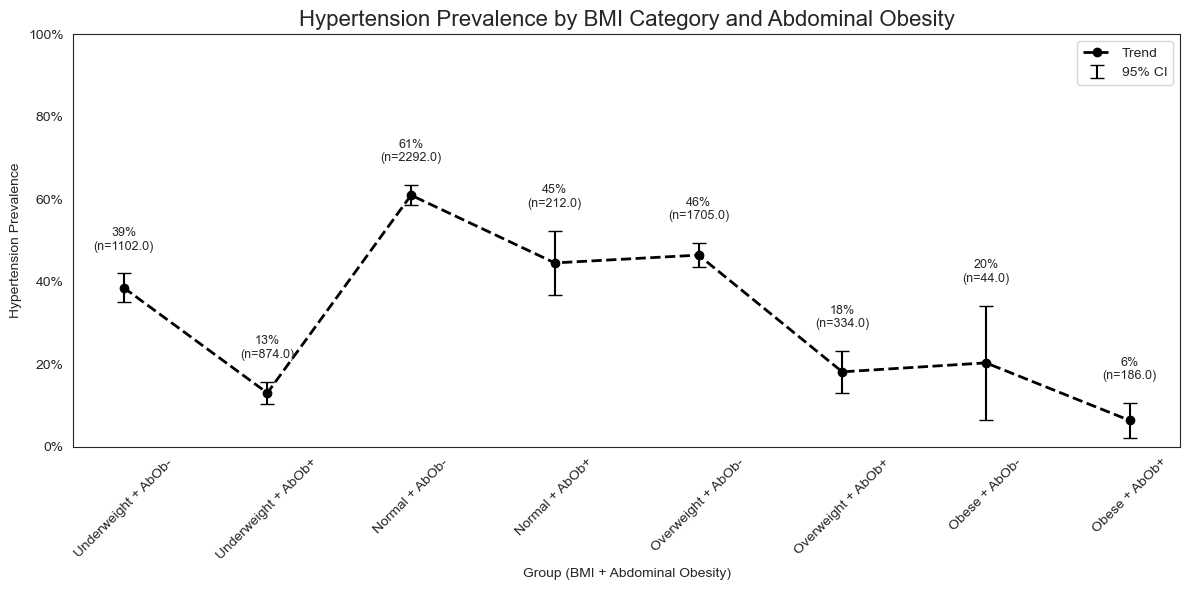

In [12]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load cleaned datasets
df_demo = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
df_bp = pd.read_csv("../data/combined_blood_pressure_data.csv")
df_bmi = pd.read_csv("../data/examination_data/cleaned_BMI_examination_data.csv")

# Step 3: Merge datasets
df = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")

# Step 4: Filter valid records
df = df[
    (df['Exam_Weight'] > 0) &
    df['BMI_Category'].notna() &
    df['Hypertensive'].notna() &
    df['Abdominal_Obesity'].notna()
]

# Step 5: Create BMI + Abdominal Obesity group label
df['BMI_Ab_Group'] = df['BMI_Category'].astype(str) + ' + ' + df['Abdominal_Obesity'].map({True: 'AbOb+', False: 'AbOb-'})

# Step 6: Compute weighted hypertension prevalence + 95% CI
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Sample_Size': len(group)  # ✅ 关键补充项
    })

grouped = df.groupby("BMI_Ab_Group").apply(compute_weighted_ci).reset_index()

# Step 7: Define order (optional but good for display)
group_order = ['Underweight + AbOb-', 'Underweight + AbOb+',
               'Normal + AbOb-', 'Normal + AbOb+',
               'Overweight + AbOb-', 'Overweight + AbOb+',
               'Obese + AbOb-', 'Obese + AbOb+']
grouped['BMI_Ab_Group'] = pd.Categorical(grouped['BMI_Ab_Group'], categories=group_order, ordered=True)
grouped = grouped.sort_values("BMI_Ab_Group")

# Step 8: Visualization
sns.set_style("white")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='BMI_Ab_Group', y='Weighted_Hypertension_Prevalence', color='skyblue', ci=None)

# Add error bars with legend
plt.errorbar(
    x=range(len(grouped)),
    y=grouped['Weighted_Hypertension_Prevalence'],
    yerr=[
        grouped['Weighted_Hypertension_Prevalence'] - grouped['CI_Lower'],
        grouped['CI_Upper'] - grouped['Weighted_Hypertension_Prevalence']
    ],
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=1.5,
    label='95% CI'
)

# Add trend line
plt.plot(
    range(len(grouped)),
    grouped['Weighted_Hypertension_Prevalence'],
    color='black',
    linestyle='--',
    marker='o',
    linewidth=2,
    label='Trend'
)

# Annotate percentage label
for i, row in grouped.iterrows():
    plt.text(
        x=i,
        y=row['CI_Upper'] + 0.05,
        s=f"{row['Weighted_Hypertension_Prevalence']*100:.0f}%\n(n={row['Sample_Size']})",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Axis & title settings
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by BMI Category and Abdominal Obesity", fontsize=16)
plt.xlabel("Group (BMI + Abdominal Obesity)")
plt.ylabel("Hypertension Prevalence")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

#Save outputs
plt.savefig("../visualization/hypertension_by_BMI_and_AbdominalObesity.png", dpi=300, bbox_inches='tight')
grouped.to_csv("../output/hypertension_by_BMI_and_AbdominalObesity.csv", index=False)
plt.show()


In [7]:
df['BMI_Ab_Group'].value_counts()

BMI_Ab_Group
obese + AbOb+          2292
overweight + AbOb+     1705
normal + AbOb+         1102
normal + AbOb-          874
overweight + AbOb-      334
obese + AbOb-           212
underweight + AbOb-     186
underweight + AbOb+      44
Name: count, dtype: int64

In [8]:
df[df['Abdominal_Obesity'].isna()].shape


(0, 36)

In [9]:
df['BMI_Ab_Group'].value_counts(dropna=False)


BMI_Ab_Group
obese + AbOb+          2292
overweight + AbOb+     1705
normal + AbOb+         1102
normal + AbOb-          874
overweight + AbOb-      334
obese + AbOb-           212
underweight + AbOb-     186
underweight + AbOb+      44
Name: count, dtype: int64